# RAG Hallucination Dissertation Experiment

This notebook runs the full experiment end-to-end and shows the results:

1. Recreates the 9 project modules (`config.py`, `retrieval.py`, `token_utils.py`, `prompts.py`, `pipelines.py`, `data_loader.py`, `evaluation.py`, `run_experiments.py`, `aggregate_winner_table.py`) in the current working directory.
2. Runs all four pipelines (`no_rag`, `basic_rag`, `improved_rag`, `context_aware_rag`) on a sample of GovReport documents.
3. Scores the summaries with ROUGE-1 and an LLM-judged factual/hallucination evaluation.
4. Aggregates everything into winner tables and shows comparison charts.

**Works in both Google Colab and Jupyter Lab.** Because step 1 writes the project files itself, you only need to upload this one `.ipynb` - no separate `.py` files required.

> **Already have a `results/` folder from a previous run?** (e.g. uploaded alongside this notebook.) You can skip straight to **7. Explore the results** near the bottom.

> **Cost/time note:** each document makes 4 LLM calls in step 4, plus several more per document in step 5 (factual evaluation). Start with a small `LIMIT` (below) before scaling up.

## 1. Install dependencies

In [3]:
# Colab already ships working numpy/pandas/matplotlib - we deliberately don't force-upgrade
# those (pip install -U on numpy mid-session is a common cause of a broken, half-upgraded
# numpy that throws ImportErrors like 'cannot import name ... from numpy._core...').
# We only install what's actually missing, and only force-upgrade huggingface_hub/fsspec,
# which need to be reasonably current for the hf:// dataset loading used below.
%pip install -q openai python-dotenv tiktoken datasets sentence-transformers tqdm pyarrow
%pip install -q -U huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 33.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.


> **If you ever add `-U` on numpy/pandas yourself (or this still shows a numpy import error), restart the runtime**: `Runtime -> Restart session`, then re-run from the API key cell onward - no need to redo this install cell or the one below it. Restarting clears Python's memory but keeps everything already installed and written to disk.

## 2. Recreate the project files

This writes out the exact modules from the consolidated project so they can be imported below.

In [2]:
import pathlib

_PROJECT_FILES = {
    'config.py': 'from dataclasses import dataclass\nimport os\nfrom dotenv import load_dotenv\n\nload_dotenv()\n\n@dataclass\nclass Config:\n    openai_api_key: str = os.getenv("OPENAI_API_KEY", "")\n    openai_model: str = os.getenv("OPENAI_MODEL", "gpt-4o-mini")\n    dataset_name: str = "abisee/cnn_dailymail"\n    dataset_config: str = "3.0.0"\n    dataset_split: str = "test"\n    chunk_size_words: int = 180\n    chunk_overlap_words: int = 40\n    max_source_tokens: int = 4_000\n    top_k: int = 5\n    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"\n    max_output_tokens: int = 220\n\nconfig = Config()\n',
    'retrieval.py': '"""\nRetrieval layer for the RAG hallucination dissertation experiment.\n\nMerged from three previously separate files (chunking.py, embeddings.py,\nand retrieval.py) because they all serve one job: turning an article into\nranked, embeddable evidence chunks.\n"""\n\nfrom __future__ import annotations\n\nfrom functools import lru_cache\nfrom typing import Any\n\nimport numpy as np\nfrom sentence_transformers import SentenceTransformer\n\n\n# ---------------------------------------------------------------------\n# Chunking\n# ---------------------------------------------------------------------\n\ndef chunk_text_by_words(\n    text: str,\n    chunk_size: int = 180,\n    overlap: int = 40\n) -> list[str]:\n    """\n    Splits text into overlapping word chunks.\n\n    Basic RAG uses fixed-size chunks.\n    Later, this can be extended into:\n    - sentence-aware chunking\n    - paragraph-aware chunking\n    - parent-child chunking\n    - context-aware chunking\n    """\n    words = text.split()\n\n    if not words:\n        return []\n\n    chunks = []\n    start = 0\n\n    while start < len(words):\n        end = start + chunk_size\n        chunk = " ".join(words[start:end])\n        chunks.append(chunk)\n\n        if end >= len(words):\n            break\n\n        start = max(0, end - overlap)\n\n    return chunks\n\n\n# ---------------------------------------------------------------------\n# Embeddings\n# ---------------------------------------------------------------------\n\n@lru_cache(maxsize=4)\ndef get_embedding_model(model_name: str):\n    return SentenceTransformer(model_name)\n\n\ndef embed_texts(texts, model_name: str):\n    """\n    Returns L2-normalised embeddings for cosine similarity.\n    """\n    model = get_embedding_model(model_name)\n    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)\n\n    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)\n    norms[norms == 0] = 1\n\n    return embeddings / norms\n\n\n# ---------------------------------------------------------------------\n# Top-k retrieval\n# ---------------------------------------------------------------------\n\ndef retrieve_top_k(\n    query: str,\n    chunks: list[str],\n    embedding_model: str,\n    top_k: int = 5\n) -> list[dict[str, Any]]:\n    """\n    Basic dense retrieval:\n    - embed query\n    - embed chunks\n    - cosine similarity\n    - return top-k chunks\n    """\n    if not chunks:\n        return []\n\n    chunk_embeddings = embed_texts(chunks, embedding_model)\n    query_embedding = embed_texts([query], embedding_model)[0]\n\n    scores = chunk_embeddings @ query_embedding\n\n    top_indices = np.argsort(scores)[::-1][:top_k]\n\n    results = []\n    for rank, idx in enumerate(top_indices, start=1):\n        results.append({\n            "rank": rank,\n            "chunk_id": int(idx),\n            "chunk": chunks[int(idx)],\n            "score": float(scores[int(idx)])\n        })\n\n    return results\n',
    'token_utils.py': 'from __future__ import annotations\n\nfrom typing import Any\n\nimport tiktoken\n\n\ndef get_token_encoding(model: str):\n    """\n    Returns the tokenizer associated with the selected OpenAI model.\n\n    If tiktoken does not recognise the model name, the function falls back\n    to the o200k_base encoding.\n    """\n    try:\n        return tiktoken.encoding_for_model(model)\n    except KeyError:\n        return tiktoken.get_encoding("o200k_base")\n\n\ndef count_tokens(text: str, model: str) -> int:\n    """\n    Counts the number of tokens in a piece of text.\n    """\n    if not text:\n        return 0\n\n    encoding = get_token_encoding(model)\n    return len(encoding.encode(text))\n\n\ndef truncate_text_to_tokens(\n    text: str,\n    max_tokens: int,\n    model: str\n) -> str:\n    """\n    Truncates text to a maximum token count.\n\n    This is used by the no-RAG pipeline so that only the first\n    max_tokens tokens of a long document are supplied to the LLM.\n    """\n    if max_tokens <= 0:\n        return ""\n\n    encoding = get_token_encoding(model)\n    encoded_text = encoding.encode(text)\n\n    if len(encoded_text) <= max_tokens:\n        return text\n\n    return encoding.decode(encoded_text[:max_tokens])\n\n\ndef select_items_within_token_budget(\n    items: list[dict[str, Any]],\n    max_tokens: int,\n    model: str,\n    text_key: str = "chunk"\n) -> list[dict[str, Any]]:\n    """\n    Selects ranked items until the source-token budget is reached.\n\n    Items are expected to already be ordered from most useful to least useful.\n\n    Whole chunks are preferred. If the first chunk alone exceeds the budget,\n    it is truncated so that the pipeline can still produce an output.\n    """\n    if max_tokens <= 0:\n        return []\n\n    selected_items: list[dict[str, Any]] = []\n    used_tokens = 0\n\n    for item in items:\n        text = str(item.get(text_key, "")).strip()\n\n        if not text:\n            continue\n\n        text_tokens = count_tokens(text, model)\n        remaining_tokens = max_tokens - used_tokens\n\n        if remaining_tokens <= 0:\n            break\n\n        if text_tokens <= remaining_tokens:\n            selected_items.append(dict(item))\n            used_tokens += text_tokens\n            continue\n\n        # Only truncate when nothing has yet been selected.\n        if not selected_items:\n            truncated_item = dict(item)\n            truncated_item[text_key] = truncate_text_to_tokens(\n                text=text,\n                max_tokens=remaining_tokens,\n                model=model\n            )\n\n            selected_items.append(truncated_item)\n\n        break\n\n    return selected_items\n\n\ndef total_item_tokens(\n    items: list[dict[str, Any]],\n    model: str,\n    text_key: str = "chunk"\n) -> int:\n    """\n    Calculates the total number of source tokens contained in selected items.\n    """\n    return sum(\n        count_tokens(str(item.get(text_key, "")), model)\n        for item in items\n    )',
    'prompts.py': '"""\nPrompt templates for the RAG hallucination dissertation experiment.\n\nThis file defines:\n1. The no-RAG generation prompt.\n2. The RAG generation prompt.\n3. One shared retrieval query used by all retrieval-based methods.\n\nExperimental rule:\nBasic RAG, Improved RAG and Context-aware RAG must use the same retrieval\nquery. The methods should differ by their retrieval strategy, not by query wording.\n"""\n\n\n# ---------------------------------------------------------------------\n# Shared retrieval query\n# ---------------------------------------------------------------------\n\ndef build_retrieval_query() -> str:\n    """\n    Return the single shared retrieval query used by all RAG methods.\n\n    This query should be used for:\n    - Basic RAG\n    - Improved RAG\n    - Context-aware RAG\n    """\n    return """\nFind the most important factual evidence needed to summarise this document.\n\nPrioritise evidence about:\n- main findings\n- recommendations\n- central issues\n- important entities\n- dates\n- numerical claims\n- causes\n- outcomes\n- conclusions\n- risks, concerns, or limitations\n""".strip()\n\n\n# Optional aliases.\n# These make the code readable while still guaranteeing the same query is used.\n\ndef build_basic_rag_query() -> str:\n    return build_retrieval_query()\n\n\ndef build_improved_rag_query() -> str:\n    return build_retrieval_query()\n\n\ndef build_context_aware_rag_query() -> str:\n    return build_retrieval_query()\n\n\n# ---------------------------------------------------------------------\n# Generation prompts\n# ---------------------------------------------------------------------\n\ndef build_no_rag_prompt(article: str) -> str:\n    return f"""\nYou are a careful academic summarisation system.\n\nTask:\nWrite a concise factual summary of the document below.\n\nRules:\n- Use only information from the document.\n- Do not add external facts.\n- Do not invent names, dates, numbers, causes, or outcomes.\n- Keep the summary around 3-5 sentences.\n\nDocument:\n{article}\n\nSummary:\n""".strip()\n\n\ndef build_rag_prompt(retrieved_chunks: list[str]) -> str:\n    if not retrieved_chunks:\n        raise ValueError("No retrieved chunks were provided to build_rag_prompt().")\n\n    evidence = "\\n\\n".join(\n        [f"[Evidence chunk {i + 1}]\\n{chunk}" for i, chunk in enumerate(retrieved_chunks)]\n    )\n\n    return f"""\nYou are a careful academic summarisation system.\n\nTask:\nWrite a concise factual summary using only the retrieved evidence below.\n\nRules:\n- Use only the retrieved evidence.\n- Do not add external facts.\n- Do not invent names, dates, numbers, causes, or outcomes.\n- If the evidence is incomplete, write a cautious summary rather than filling gaps.\n- Keep the summary around 3-5 sentences.\n\nRetrieved evidence:\n{evidence}\n\nSummary:\n""".strip()',
    'pipelines.py': 'from __future__ import annotations\n\nfrom typing import Any\n\nfrom openai import OpenAI\n\nfrom config import config\nfrom prompts import build_no_rag_prompt, build_rag_prompt, build_retrieval_query\nfrom retrieval import chunk_text_by_words, retrieve_top_k\nfrom token_utils import (\n    count_tokens,\n    select_items_within_token_budget,\n    total_item_tokens,\n    truncate_text_to_tokens,\n)\n\n\n# ---------------------------------------------------------------------\n# Generation\n# ---------------------------------------------------------------------\n# Folded in from generator.py, which existed only as a one-function\n# wrapper used exclusively by the pipelines below.\n\ndef generate_with_openai(prompt: str) -> str:\n    """\n    Fixed LLM generator wrapper.\n\n    The same generator is used across all experiment conditions\n    so that only the retrieval strategy changes.\n    """\n    if not config.openai_api_key:\n        raise RuntimeError(\n            "OPENAI_API_KEY is missing. Create a .env file in the main project folder "\n            "or export OPENAI_API_KEY in your terminal."\n        )\n\n    client = OpenAI(api_key=config.openai_api_key)\n\n    response = client.responses.create(\n        model=config.openai_model,\n        input=prompt,\n        max_output_tokens=config.max_output_tokens,\n        temperature=0.2\n    )\n\n    return response.output_text.strip()\n\n\n# ---------------------------------------------------------------------\n# No-RAG baseline\n# ---------------------------------------------------------------------\n\ndef no_rag_pipeline(article: str) -> dict[str, Any]:\n    """\n    No-RAG baseline.\n\n    The pipeline does not perform retrieval. When the article exceeds the\n    experimental source budget, only its first max_source_tokens tokens are\n    supplied to the LLM.\n    """\n    original_article_tokens = count_tokens(\n        article,\n        model=config.openai_model\n    )\n\n    limited_article = truncate_text_to_tokens(\n        text=article,\n        max_tokens=config.max_source_tokens,\n        model=config.openai_model\n    )\n\n    source_tokens_sent = count_tokens(\n        limited_article,\n        model=config.openai_model\n    )\n\n    prompt = build_no_rag_prompt(limited_article)\n    summary = generate_with_openai(prompt)\n\n    return {\n        "pipeline_name": "no_rag",\n        "retrieved_chunks": [],\n        "retrieval_scores": [],\n        "prompt": prompt,\n        "generated_summary": summary,\n        "original_article_tokens": original_article_tokens,\n        "source_tokens_sent": source_tokens_sent,\n        "source_truncated": original_article_tokens > source_tokens_sent,\n    }\n\n\n# ---------------------------------------------------------------------\n# Basic RAG\n# ---------------------------------------------------------------------\n\ndef basic_rag_pipeline(article: str) -> dict[str, Any]:\n    """\n    Basic RAG pipeline.\n\n    The entire article is chunked and searched. Ranked chunks are then selected\n    until the 8,000-token experimental source budget is reached.\n    """\n    original_article_tokens = count_tokens(\n        article,\n        model=config.openai_model\n    )\n\n    chunks = chunk_text_by_words(\n        article,\n        chunk_size=config.chunk_size_words,\n        overlap=config.chunk_overlap_words\n    )\n\n    retrieval_query = build_retrieval_query()\n\n    # Return the complete ranking so that chunks can be accumulated\n    # until the token budget is reached.\n    ranked_items = retrieve_top_k(\n        query=retrieval_query,\n        chunks=chunks,\n        embedding_model=config.embedding_model,\n        top_k=len(chunks)\n    )\n\n    selected_items = select_items_within_token_budget(\n        items=ranked_items,\n        max_tokens=config.max_source_tokens,\n        model=config.openai_model\n    )\n\n    retrieved_chunks = [\n        item["chunk"]\n        for item in selected_items\n    ]\n\n    retrieval_scores = [\n        item["score"]\n        for item in selected_items\n    ]\n\n    source_tokens_sent = total_item_tokens(\n        selected_items,\n        model=config.openai_model\n    )\n\n    prompt = build_rag_prompt(retrieved_chunks)\n    summary = generate_with_openai(prompt)\n\n    return {\n        "pipeline_name": "basic_rag",\n        "retrieved_chunks": retrieved_chunks,\n        "retrieval_scores": retrieval_scores,\n        "prompt": prompt,\n        "generated_summary": summary,\n        "original_article_tokens": original_article_tokens,\n        "source_tokens_sent": source_tokens_sent,\n        "source_truncated": source_tokens_sent < original_article_tokens,\n    }\n\n\n# ---------------------------------------------------------------------\n# Improved RAG helpers (reranking, keywords, dedup)\n# ---------------------------------------------------------------------\n\ndef keyword_overlap_score(\n    text: str,\n    keywords: list[str]\n) -> int:\n    """\n    Counts how many article-specific keywords appear in a chunk.\n    """\n    text_lower = text.lower()\n\n    return sum(\n        1\n        for keyword in keywords\n        if keyword.lower() in text_lower\n    )\n\n\ndef extract_keywords_from_opening(\n    article_opening: str\n) -> list[str]:\n    """\n    Extracts simple article-specific keywords from the opening of the article.\n    """\n    stopwords = {\n        "the", "and", "for", "that", "with", "this", "from", "have", "has",\n        "was", "were", "are", "but", "not", "you", "they", "their", "his",\n        "her", "its", "who", "what", "when", "where", "which", "will",\n        "would", "could", "should", "about", "after", "before", "into",\n        "over", "under", "than", "then", "there", "been", "being", "also",\n        "said", "says", "can", "had", "did", "out", "one", "two", "new",\n        "more", "most", "some", "such", "while", "during", "through",\n        "between", "against", "because"\n    }\n\n    words = article_opening.replace("\\n", " ").split()\n\n    cleaned_words: list[str] = []\n\n    for word in words:\n        cleaned = word.strip(\n            ".,;:!?()[]{}\\"\'"\n        ).lower()\n\n        if len(cleaned) > 3 and cleaned not in stopwords:\n            cleaned_words.append(cleaned)\n\n    keywords: list[str] = []\n    seen: set[str] = set()\n\n    for word in cleaned_words:\n        if word not in seen:\n            keywords.append(word)\n            seen.add(word)\n\n    return keywords[:30]\n\n\ndef remove_near_duplicate_chunks(\n    retrieved_items: list[dict[str, Any]]\n) -> list[dict[str, Any]]:\n    """\n    Removes chunks that have very high word overlap with chunks already kept.\n    """\n    selected: list[dict[str, Any]] = []\n\n    for item in retrieved_items:\n        current_chunk = item["chunk"].strip().lower()\n        current_words = set(current_chunk.split())\n\n        if not current_words:\n            continue\n\n        is_duplicate = False\n\n        for selected_item in selected:\n            selected_chunk = selected_item["chunk"].strip().lower()\n            selected_words = set(selected_chunk.split())\n\n            if not selected_words:\n                continue\n\n            overlap = len(\n                current_words.intersection(selected_words)\n            )\n\n            overlap_ratio = overlap / min(\n                len(current_words),\n                len(selected_words)\n            )\n\n            if overlap_ratio > 0.75:\n                is_duplicate = True\n                break\n\n        if not is_duplicate:\n            selected.append(item)\n\n    return selected\n\n\ndef create_improved_ranking(\n    article: str,\n    chunks: list[str]\n) -> list[dict[str, Any]]:\n    """\n    Creates the reranked and deduplicated chunk ranking used by both\n    improved RAG and context-aware RAG.\n\n    The initial retrieval query is the same shared query used by all\n    RAG-based methods. Improved RAG differs from basic RAG through\n    reranking, keyword overlap scoring and near-duplicate removal,\n    not through different query wording.\n    """\n    article_opening = article[:1000]\n\n    retrieval_query = build_retrieval_query()\n\n    # Retrieve the complete ranking because the final number of chunks\n    # is determined by the token budget rather than a fixed top-k value.\n    candidate_items = retrieve_top_k(\n        query=retrieval_query,\n        chunks=chunks,\n        embedding_model=config.embedding_model,\n        top_k=len(chunks)\n    )\n\n    keywords = extract_keywords_from_opening(article_opening)\n\n    reranked_items: list[dict[str, Any]] = []\n\n    for item in candidate_items:\n        chunk = item["chunk"]\n        embedding_score = float(item["score"])\n        keyword_score = keyword_overlap_score(chunk, keywords)\n\n        combined_score = embedding_score + (\n            0.02 * keyword_score\n        )\n\n        reranked_items.append({\n            "chunk": chunk,\n            "score": combined_score,\n            "original_embedding_score": embedding_score,\n            "keyword_score": keyword_score,\n        })\n\n    reranked_items.sort(\n        key=lambda item: item["score"],\n        reverse=True\n    )\n\n    return remove_near_duplicate_chunks(reranked_items)\n\n\ndef improved_rag_pipeline(article: str) -> dict[str, Any]:\n    """\n    Improved RAG pipeline.\n\n    The full article is searched, candidates are reranked and deduplicated,\n    and final evidence is selected within the 8,000-token source budget.\n    """\n    original_article_tokens = count_tokens(\n        article,\n        model=config.openai_model\n    )\n\n    chunks = chunk_text_by_words(\n        article,\n        chunk_size=config.chunk_size_words,\n        overlap=config.chunk_overlap_words\n    )\n\n    ranked_items = create_improved_ranking(\n        article=article,\n        chunks=chunks\n    )\n\n    selected_items = select_items_within_token_budget(\n        items=ranked_items,\n        max_tokens=config.max_source_tokens,\n        model=config.openai_model\n    )\n\n    retrieved_chunks = [\n        item["chunk"]\n        for item in selected_items\n    ]\n\n    retrieval_scores = [\n        item["score"]\n        for item in selected_items\n    ]\n\n    source_tokens_sent = total_item_tokens(\n        selected_items,\n        model=config.openai_model\n    )\n\n    prompt = build_rag_prompt(retrieved_chunks)\n    summary = generate_with_openai(prompt)\n\n    return {\n        "pipeline_name": "improved_rag",\n        "retrieved_chunks": retrieved_chunks,\n        "retrieval_scores": retrieval_scores,\n        "prompt": prompt,\n        "generated_summary": summary,\n        "original_article_tokens": original_article_tokens,\n        "source_tokens_sent": source_tokens_sent,\n        "source_truncated": source_tokens_sent < original_article_tokens,\n    }\n\n\n# ---------------------------------------------------------------------\n# Context-aware RAG\n# ---------------------------------------------------------------------\n\ndef find_chunk_index(\n    chunks: list[str],\n    target_chunk: str\n) -> int:\n    """\n    Finds the original position of a retrieved chunk.\n    """\n    target_clean = target_chunk.strip()\n\n    for index, chunk in enumerate(chunks):\n        if chunk.strip() == target_clean:\n            return index\n\n    # Fallback for minor text differences.\n    target_prefix = target_clean[:100]\n\n    for index, chunk in enumerate(chunks):\n        chunk_clean = chunk.strip()\n\n        if (\n            target_prefix in chunk_clean\n            or chunk_clean[:100] in target_clean\n        ):\n            return index\n\n    return -1\n\n\ndef expand_with_context_within_budget(\n    chunks: list[str],\n    ranked_items: list[dict[str, Any]],\n    max_tokens: int,\n    model: str,\n    window_size: int = 1\n) -> list[dict[str, Any]]:\n    """\n    Selects retrieved chunks and neighbouring chunks while respecting the\n    source-token budget.\n\n    Ranked seed chunks are processed from strongest to weakest. For each seed,\n    the function attempts to include the previous chunk, seed chunk and next\n    chunk. Duplicate chunk positions are not added twice.\n    """\n    selected_by_index: dict[int, dict[str, Any]] = {}\n    used_tokens = 0\n\n    for item in ranked_items:\n        centre_index = find_chunk_index(\n            chunks=chunks,\n            target_chunk=item["chunk"]\n        )\n\n        if centre_index == -1:\n            continue\n\n        start_index = max(\n            0,\n            centre_index - window_size\n        )\n\n        end_index = min(\n            len(chunks),\n            centre_index + window_size + 1\n        )\n\n        candidate_indices = list(\n            range(start_index, end_index)\n        )\n\n        # Prioritise the retrieved seed before its neighbours.\n        candidate_indices.sort(\n            key=lambda index: (\n                0 if index == centre_index else 1,\n                index\n            )\n        )\n\n        for chunk_index in candidate_indices:\n            if chunk_index in selected_by_index:\n                continue\n\n            chunk_text = chunks[chunk_index]\n            chunk_tokens = count_tokens(\n                chunk_text,\n                model=model\n            )\n\n            if used_tokens + chunk_tokens > max_tokens:\n                continue\n\n            selected_by_index[chunk_index] = {\n                "chunk_index": chunk_index,\n                "chunk": chunk_text,\n                "score": item["score"],\n                "source": (\n                    "retrieved"\n                    if chunk_index == centre_index\n                    else "neighbour"\n                ),\n            }\n\n            used_tokens += chunk_tokens\n\n        if used_tokens >= max_tokens:\n            break\n\n    # Present evidence in original article order so that chronology and\n    # surrounding meaning are easier for the generator to follow.\n    return [\n        selected_by_index[index]\n        for index in sorted(selected_by_index)\n    ]\n\n\ndef context_aware_rag_pipeline(\n    article: str\n) -> dict[str, Any]:\n    """\n    Context-aware RAG pipeline.\n\n    The full article is searched using the improved retrieval strategy.\n    Selected chunks are expanded with neighbouring chunks, but the combined\n    evidence remains within the same 8,000-token source budget.\n    """\n    original_article_tokens = count_tokens(\n        article,\n        model=config.openai_model\n    )\n\n    chunks = chunk_text_by_words(\n        article,\n        chunk_size=config.chunk_size_words,\n        overlap=config.chunk_overlap_words\n    )\n\n    ranked_items = create_improved_ranking(\n        article=article,\n        chunks=chunks\n    )\n\n    expanded_items = expand_with_context_within_budget(\n        chunks=chunks,\n        ranked_items=ranked_items,\n        max_tokens=config.max_source_tokens,\n        model=config.openai_model,\n        window_size=1\n    )\n\n    retrieved_chunks = [\n        item["chunk"]\n        for item in expanded_items\n    ]\n\n    retrieval_scores = [\n        item["score"]\n        for item in expanded_items\n    ]\n\n    source_tokens_sent = total_item_tokens(\n        expanded_items,\n        model=config.openai_model\n    )\n\n    prompt = build_rag_prompt(retrieved_chunks)\n    summary = generate_with_openai(prompt)\n\n    return {\n        "pipeline_name": "context_aware_rag",\n        "retrieved_chunks": retrieved_chunks,\n        "retrieval_scores": retrieval_scores,\n        "prompt": prompt,\n        "generated_summary": summary,\n        "original_article_tokens": original_article_tokens,\n        "source_tokens_sent": source_tokens_sent,\n        "source_truncated": source_tokens_sent < original_article_tokens,\n    }\n',
    'data_loader.py': 'from __future__ import annotations\n\nimport pandas as pd\nfrom datasets import load_dataset\n\nfrom config import config\nfrom token_utils import count_tokens\n\n\ndef load_govreport_sample(\n    limit: int = 5,\n    minimum_tokens: int | None = None,\n    split: str = "test",\n) -> pd.DataFrame:\n    """\n    Loads long GovReport documents directly from Hugging Face\'s\n    auto-converted Parquet files.\n\n    This avoids running the deprecated gov_report.py dataset script.\n\n    Only documents containing more than the required minimum number\n    of tokens are retained.\n\n    Args:\n        limit:\n            Number of qualifying documents to return.\n\n        minimum_tokens:\n            Minimum source-document token count. If omitted, this uses\n            config.max_source_tokens.\n\n        split:\n            Dataset split to use: "train", "validation", or "test".\n\n    Returns:\n        A pandas DataFrame containing:\n        - document_id\n        - dataset_name\n        - article\n        - reference_summary\n        - original_article_tokens\n    """\n    if limit <= 0:\n        raise ValueError("limit must be greater than zero.")\n\n    if minimum_tokens is None:\n        minimum_tokens = config.max_source_tokens\n\n    if minimum_tokens <= 0:\n        raise ValueError("minimum_tokens must be greater than zero.")\n\n    valid_splits = {"train", "validation", "test"}\n\n    if split not in valid_splits:\n        raise ValueError(\n            f"Invalid split \'{split}\'. "\n            f"Choose one of: {sorted(valid_splits)}"\n        )\n\n    # These paths point directly to Hugging Face\'s converted Parquet files.\n    # Using @refs/convert/parquet prevents datasets from attempting to run\n    # the deprecated gov_report.py loading script.\n    data_files = {\n        "train": (\n            "hf://datasets/launch/gov_report@refs/convert/parquet/"\n            "plain_text/train/0000.parquet"\n        ),\n        "validation": (\n            "hf://datasets/launch/gov_report@refs/convert/parquet/"\n            "plain_text/validation/0000.parquet"\n        ),\n        "test": (\n            "hf://datasets/launch/gov_report@refs/convert/parquet/"\n            "plain_text/test/0000.parquet"\n        ),\n    }\n\n    try:\n        dataset = load_dataset(\n            "parquet",\n            data_files={split: data_files[split]},\n            split=split,\n            streaming=True,\n        )\n    except Exception as error:\n        raise RuntimeError(\n            "GovReport could not be loaded from the direct Parquet file. "\n            "Check your internet connection and ensure that datasets, "\n            "huggingface_hub, fsspec and pyarrow are installed and updated."\n        ) from error\n\n    rows: list[dict[str, object]] = []\n    inspected_count = 0\n\n    for item in dataset:\n        inspected_count += 1\n\n        # GovReport\'s plain-text fields are:\n        # id, document and summary.\n        article = str(\n            item.get("document", "")\n        ).strip()\n\n        reference_summary = str(\n            item.get("summary", "")\n        ).strip()\n\n        if not article or not reference_summary:\n            continue\n\n        article_tokens = count_tokens(\n            article,\n            model=config.openai_model,\n        )\n\n        # Keep only documents that exceed the experimental source budget.\n        if article_tokens <= minimum_tokens:\n            continue\n\n        raw_source_id = item.get("id")\n\n        if raw_source_id is None:\n            source_id = str(inspected_count)\n        else:\n            source_id = str(raw_source_id).strip()\n\n        rows.append({\n            "document_id": f"govreport_{source_id}",\n            "dataset_name": "govreport",\n            "article": article,\n            "reference_summary": reference_summary,\n            "original_article_tokens": article_tokens,\n        })\n\n        print(\n            f"Selected GovReport document "\n            f"{len(rows)}/{limit}: "\n            f"{article_tokens:,} tokens"\n        )\n\n        if len(rows) >= limit:\n            break\n\n    if not rows:\n        raise ValueError(\n            "No GovReport documents exceeded the required "\n            f"{minimum_tokens:,}-token minimum after inspecting "\n            f"{inspected_count:,} records."\n        )\n\n    if len(rows) < limit:\n        print(\n            f"Warning: requested {limit} documents, but only "\n            f"{len(rows)} qualifying documents were found after "\n            f"inspecting {inspected_count:,} records."\n        )\n\n    dataframe = pd.DataFrame(rows)\n\n    print(f"\\nLoaded {len(dataframe)} GovReport documents.")\n    print(\n        "Token range: "\n        f"{int(dataframe[\'original_article_tokens\'].min()):,}–"\n        f"{int(dataframe[\'original_article_tokens\'].max()):,}"\n    )\n\n    return dataframe\n\n',
    'evaluation.py': '"""\nEvaluation layer for the RAG hallucination dissertation experiment.\n\nMerged from two previously separate files (evaluation.py and\nfactual_evaluation.py) because both are "how good is this summary?"\nmetrics - they just differ in how they compute the answer.\n\nSection 1: ROUGE-1 lexical overlap metrics.\n    Fast, deterministic, purely reference-based. Used inline by\n    run_experiments.py while pipelines are running.\n\nSection 2: LLM-based factual evaluation.\n    Hallucination rate, factual precision and importance-weighted\n    key-fact recall, judged by an OpenAI model against the source\n    evidence. This section is also a standalone CLI script that runs\n    over a saved results CSV, unchanged in behaviour from the original\n    factual_evaluation.py - only the file/entry-point name changes:\n\n        python evaluation.py --input results/summaries.csv \\\\\n            --output-dir results/factual_eval --budget 4000\n\n    It still writes factual_key_facts.csv, factual_claims.csv and\n    factual_metrics.csv, exactly as before, so aggregate_winner_table.py\n    needs no changes.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport os\nimport re\nimport time\nfrom collections import Counter\nfrom pathlib import Path\nfrom typing import Any\n\nimport pandas as pd\nfrom dotenv import load_dotenv\nfrom openai import OpenAI\n\nload_dotenv()\n\n\n# ---------------------------------------------------------------------\n# Shared helpers\n# ---------------------------------------------------------------------\n\ndef safe_divide(numerator: float, denominator: float) -> float:\n    if denominator == 0:\n        return 0.0\n    return numerator / denominator\n\n\ndef f1_score(precision: float, recall: float) -> float:\n    """\n    Harmonic mean of precision and recall.\n\n    Shared by both the ROUGE-1 metrics below and the LLM-based factual\n    F1 score - these were two identical functions (f1_score / harmonic_f1)\n    in the original files.\n    """\n    if precision + recall == 0:\n        return 0.0\n    return 2 * precision * recall / (precision + recall)\n\n\n# Alias kept in case other scripts still refer to the factual_evaluation.py name.\nharmonic_f1 = f1_score\n\n\n# ---------------------------------------------------------------------\n# Section 1: ROUGE-1 lexical overlap metrics\n# ---------------------------------------------------------------------\n\ndef normalise(text: str) -> list[str]:\n    text = text.lower()\n    text = re.sub(r"[^a-z0-9\\s]", " ", text)\n    return [w for w in text.split() if w]\n\n\ndef rouge_1_recall(generated: str, reference: str) -> float:\n    """\n    Simple ROUGE-1 recall implementation:\n    overlapping unigrams / total unigrams in reference.\n    """\n    gen_words = normalise(generated)\n    ref_words = normalise(reference)\n\n    if not ref_words:\n        return 0.0\n\n    gen_counts = Counter(gen_words)\n    ref_counts = Counter(ref_words)\n\n    overlap = sum(min(ref_counts[w], gen_counts.get(w, 0)) for w in ref_counts)\n\n    return overlap / len(ref_words)\n\n\ndef rouge_1_precision(generated: str, reference: str) -> float:\n    gen_words = normalise(generated)\n    ref_words = normalise(reference)\n\n    if not gen_words:\n        return 0.0\n\n    gen_counts = Counter(gen_words)\n    ref_counts = Counter(ref_words)\n\n    overlap = sum(min(gen_counts[w], ref_counts.get(w, 0)) for w in gen_counts)\n\n    return overlap / len(gen_words)\n\n\ndef rouge_1_f1(generated: str, reference: str) -> float:\n    p = rouge_1_precision(generated, reference)\n    r = rouge_1_recall(generated, reference)\n    return f1_score(p, r)\n\n\n# ---------------------------------------------------------------------\n# Section 2: LLM-based factual / hallucination evaluation\n# ---------------------------------------------------------------------\n\n# JSON schemas for evaluator LLM\nKEY_FACT_SCHEMA: dict[str, Any] = {\n    "name": "key_fact_extraction",\n    "strict": True,\n    "schema": {\n        "type": "object",\n        "properties": {\n            "key_facts": {\n                "type": "array",\n                "items": {\n                    "type": "object",\n                    "properties": {\n                        "key_fact_id": {"type": "string"},\n                        "fact": {"type": "string"},\n                        "importance": {\n                            "type": "string",\n                            "enum": ["high", "medium", "low"],\n                        },\n                        "weight": {"type": "integer", "enum": [3, 2, 1]},\n                    },\n                    "required": [\n                        "key_fact_id",\n                        "fact",\n                        "importance",\n                        "weight",\n                    ],\n                    "additionalProperties": False,\n                },\n            }\n        },\n        "required": ["key_facts"],\n        "additionalProperties": False,\n    },\n}\n\nCLAIM_EVAL_SCHEMA: dict[str, Any] = {\n    "name": "summary_factual_evaluation",\n    "strict": True,\n    "schema": {\n        "type": "object",\n        "properties": {\n            "claims": {\n                "type": "array",\n                "items": {\n                    "type": "object",\n                    "properties": {\n                        "claim_id": {"type": "string"},\n                        "claim": {"type": "string"},\n                        "label": {\n                            "type": "string",\n                            "enum": [\n                                "supported",\n                                "unsupported",\n                                "contradicted",\n                                "unclear",\n                            ],\n                        },\n                        "evidence_quote": {"type": "string"},\n                        "reason": {"type": "string"},\n                    },\n                    "required": [\n                        "claim_id",\n                        "claim",\n                        "label",\n                        "evidence_quote",\n                        "reason",\n                    ],\n                    "additionalProperties": False,\n                },\n            },\n            "key_fact_coverage": {\n                "type": "array",\n                "items": {\n                    "type": "object",\n                    "properties": {\n                        "key_fact_id": {"type": "string"},\n                        "covered": {"type": "boolean"},\n                        "reason": {"type": "string"},\n                    },\n                    "required": ["key_fact_id", "covered", "reason"],\n                    "additionalProperties": False,\n                },\n            },\n        },\n        "required": ["claims", "key_fact_coverage"],\n        "additionalProperties": False,\n    },\n}\n\n\ndef read_json_response(response: Any) -> dict[str, Any]:\n    """Extract and parse the JSON content from Chat Completions."""\n    content = response.choices[0].message.content\n    if not content:\n        raise ValueError("The evaluator returned an empty response.")\n    return json.loads(content)\n\n\ndef call_structured_llm(\n    client: OpenAI,\n    model: str,\n    messages: list[dict[str, str]],\n    schema: dict[str, Any],\n    max_retries: int = 3,\n) -> dict[str, Any]:\n    """Call OpenAI with a strict JSON schema and retry transient failures."""\n    last_error: Exception | None = None\n\n    for attempt in range(1, max_retries + 1):\n        try:\n            response = client.chat.completions.create(\n                model=model,\n                messages=messages,\n                temperature=0,\n                response_format={\n                    "type": "json_schema",\n                    "json_schema": schema,\n                },\n            )\n            return read_json_response(response)\n        except Exception as error:\n            last_error = error\n            if attempt == max_retries:\n                break\n            time.sleep(2 * attempt)\n\n    raise RuntimeError(f"Evaluator failed after {max_retries} attempts: {last_error}")\n\n\ndef maybe_trim(text: str, max_chars: int) -> str:\n    """\n    Optional safety trim.\n    Set max_chars to 0 or a negative number to disable trimming.\n    """\n    if max_chars and max_chars > 0 and len(text) > max_chars:\n        return text[:max_chars]\n    return text\n\n\ndef extract_key_facts(\n    client: OpenAI,\n    model: str,\n    document_id: str,\n    reference_summary: str,\n) -> list[dict[str, Any]]:\n    """\n    Extract salient key facts from the human reference summary.\n    This makes key-fact recall a salience/completeness metric.\n    """\n    messages = [\n        {\n            "role": "system",\n            "content": (\n                "You are evaluating long-document summarisation. "\n                "Extract atomic key facts from the human reference summary. "\n                "Each key fact must be a standalone factual proposition. "\n                "Use high importance for central findings, recommendations, "\n                "conclusions, major outcomes, major numerical claims, or core entities. "\n                "Use medium for important supporting facts. "\n                "Use low for minor context."\n            ),\n        },\n        {\n            "role": "user",\n            "content": (\n                f"Document ID: {document_id}\\n\\n"\n                "Human reference summary:\\n"\n                f"{reference_summary}\\n\\n"\n                "Extract around 5-12 atomic key facts. "\n                "Assign ids KF1, KF2, KF3, etc."\n            ),\n        },\n    ]\n\n    output = call_structured_llm(\n        client=client,\n        model=model,\n        messages=messages,\n        schema=KEY_FACT_SCHEMA,\n    )\n\n    return output["key_facts"]\n\n\ndef evaluate_summary_factuality(\n    client: OpenAI,\n    model: str,\n    document_id: str,\n    pipeline_name: str,\n    evidence_text: str,\n    generated_summary: str,\n    key_facts: list[dict[str, Any]],\n) -> dict[str, Any]:\n    """\n    Evaluate generated summary claims against the source/evidence text,\n    and evaluate whether the summary covers the extracted salient key facts.\n    """\n    key_facts_json = json.dumps(key_facts, ensure_ascii=False, indent=2)\n\n    messages = [\n        {\n            "role": "system",\n            "content": (\n                "You are a strict factual evaluator for long-document summarisation. "\n                "Use only the provided source evidence when judging support. "\n                "Do not use outside knowledge. "\n                "Break the generated summary into atomic factual claims. "\n                "Label each claim as supported, unsupported, contradicted, or unclear. "\n                "Supported means the source evidence directly supports the claim. "\n                "Unsupported means the claim is not found in the source evidence. "\n                "Contradicted means the source evidence conflicts with the claim. "\n                "Unclear means the claim is too vague or there is insufficient evidence to judge. "\n                "Then decide which key facts are covered by the generated summary."\n            ),\n        },\n        {\n            "role": "user",\n            "content": (\n                f"Document ID: {document_id}\\n"\n                f"Method: {pipeline_name}\\n\\n"\n                "Source evidence:\\n"\n                f"{evidence_text}\\n\\n"\n                "Generated summary:\\n"\n                f"{generated_summary}\\n\\n"\n                "Key facts to check for coverage:\\n"\n                f"{key_facts_json}\\n\\n"\n                "Return claim-level labels and key-fact coverage. "\n                "For supported claims, include a short evidence_quote. "\n                "For unsupported, contradicted, or unclear claims, evidence_quote can be an empty string."\n            ),\n        },\n    ]\n\n    return call_structured_llm(\n        client=client,\n        model=model,\n        messages=messages,\n        schema=CLAIM_EVAL_SCHEMA,\n    )\n\n\ndef run_factual_evaluation(\n    input_path: Path,\n    output_dir: Path,\n    budget: int,\n    model: str,\n    evidence_column: str,\n    max_evidence_chars: int,\n    limit_rows: int | None,\n) -> None:\n    api_key = os.getenv("OPENAI_API_KEY")\n    if not api_key:\n        raise RuntimeError("OPENAI_API_KEY is missing from your environment.")\n\n    output_dir.mkdir(parents=True, exist_ok=True)\n\n    df = pd.read_csv(input_path)\n\n    required = {\n        "document_id",\n        "pipeline_name",\n        "reference_summary",\n        "generated_summary",\n        evidence_column,\n    }\n    missing = required.difference(df.columns)\n    if missing:\n        raise ValueError(f"Input file is missing required columns: {sorted(missing)}")\n\n    if limit_rows is not None:\n        df = df.head(limit_rows).copy()\n\n    client = OpenAI(api_key=api_key)\n\n    key_fact_rows: list[dict[str, Any]] = []\n    claim_rows: list[dict[str, Any]] = []\n    metric_rows: list[dict[str, Any]] = []\n\n    key_facts_by_doc: dict[str, list[dict[str, Any]]] = {}\n\n    # Extract key facts once per document.\n    for document_id, doc_group in df.groupby("document_id", sort=False):\n        reference_summary = str(doc_group.iloc[0]["reference_summary"])\n        print(f"Extracting key facts for {document_id}...")\n\n        key_facts = extract_key_facts(\n            client=client,\n            model=model,\n            document_id=str(document_id),\n            reference_summary=reference_summary,\n        )\n        key_facts_by_doc[str(document_id)] = key_facts\n\n        for fact in key_facts:\n            key_fact_rows.append({\n                "document_id": document_id,\n                "budget": budget,\n                **fact,\n            })\n\n    # Evaluate every generated summary.\n    for idx, row in df.iterrows():\n        document_id = str(row["document_id"])\n        pipeline_name = str(row["pipeline_name"])\n        generated_summary = str(row["generated_summary"])\n        evidence_text = maybe_trim(str(row[evidence_column]), max_evidence_chars)\n        key_facts = key_facts_by_doc[document_id]\n\n        print(f"Evaluating {idx + 1}/{len(df)}: {document_id} | {pipeline_name}")\n\n        evaluation = evaluate_summary_factuality(\n            client=client,\n            model=model,\n            document_id=document_id,\n            pipeline_name=pipeline_name,\n            evidence_text=evidence_text,\n            generated_summary=generated_summary,\n            key_facts=key_facts,\n        )\n\n        labels = [claim["label"] for claim in evaluation["claims"]]\n        supported = labels.count("supported")\n        unsupported = labels.count("unsupported")\n        contradicted = labels.count("contradicted")\n        unclear = labels.count("unclear")\n        total_claims = len(labels)\n\n        # Main factual metrics exclude unclear claims from the denominator.\n        # Keep unclear_rate separately for transparency.\n        verifiable_claims = supported + unsupported + contradicted\n        hallucinated_claims = unsupported + contradicted\n\n        factual_precision = safe_divide(supported, verifiable_claims)\n        hallucination_rate = safe_divide(hallucinated_claims, verifiable_claims)\n        unclear_rate = safe_divide(unclear, total_claims)\n\n        covered_ids = {\n            item["key_fact_id"]\n            for item in evaluation["key_fact_coverage"]\n            if item["covered"]\n        }\n        total_weight = sum(float(fact["weight"]) for fact in key_facts)\n        covered_weight = sum(\n            float(fact["weight"])\n            for fact in key_facts\n            if fact["key_fact_id"] in covered_ids\n        )\n\n        key_fact_recall = safe_divide(covered_weight, total_weight)\n        factual_f1 = f1_score(factual_precision, key_fact_recall)\n\n        for claim in evaluation["claims"]:\n            claim_rows.append({\n                "document_id": document_id,\n                "budget": budget,\n                "pipeline_name": pipeline_name,\n                **claim,\n            })\n\n        # Save key-fact coverage in a compact JSON string for auditability.\n        metric_rows.append({\n            "document_id": document_id,\n            "budget": budget,\n            "pipeline_name": pipeline_name,\n            "total_claims": total_claims,\n            "verifiable_claims": verifiable_claims,\n            "supported_claims": supported,\n            "unsupported_claims": unsupported,\n            "contradicted_claims": contradicted,\n            "unclear_claims": unclear,\n            "hallucinated_claims": hallucinated_claims,\n            "hallucination_rate": hallucination_rate,\n            "factual_precision": factual_precision,\n            "unclear_rate": unclear_rate,\n            "key_fact_total_weight": total_weight,\n            "key_fact_covered_weight": covered_weight,\n            "importance_weighted_key_fact_recall": key_fact_recall,\n            "factual_f1": factual_f1,\n            "key_fact_coverage_json": json.dumps(\n                evaluation["key_fact_coverage"],\n                ensure_ascii=False,\n            ),\n        })\n\n        # Incremental saves, useful for long runs.\n        pd.DataFrame(key_fact_rows).to_csv(output_dir / "factual_key_facts.csv", index=False)\n        pd.DataFrame(claim_rows).to_csv(output_dir / "factual_claims.csv", index=False)\n        pd.DataFrame(metric_rows).to_csv(output_dir / "factual_metrics.csv", index=False)\n\n    print("\\nDone.")\n    print(f"Saved: {output_dir / \'factual_key_facts.csv\'}")\n    print(f"Saved: {output_dir / \'factual_claims.csv\'}")\n    print(f"Saved: {output_dir / \'factual_metrics.csv\'}")\n\n\ndef parse_args() -> argparse.Namespace:\n    parser = argparse.ArgumentParser(\n        description="Calculate hallucination, factual precision, key-fact recall and factual F1 from existing summaries."\n    )\n    parser.add_argument("--input", required=True, type=Path, help="Path to summaries/results CSV.")\n    parser.add_argument("--output-dir", required=True, type=Path, help="Directory to write factual evaluation CSVs.")\n    parser.add_argument("--budget", required=True, type=int, help="Context budget label, e.g. 4000.")\n    parser.add_argument("--model", default=os.getenv("OPENAI_EVAL_MODEL", "gpt-4o-mini"))\n    parser.add_argument(\n        "--evidence-column",\n        default="article",\n        help="Column used as source evidence. Use \'article\' for full-source factuality or \'prompt\' for prompt-grounded factuality.",\n    )\n    parser.add_argument(\n        "--max-evidence-chars",\n        type=int,\n        default=0,\n        help="Optional char limit for source evidence. 0 means no trimming.",\n    )\n    parser.add_argument(\n        "--limit-rows",\n        type=int,\n        default=None,\n        help="Optional test mode: only evaluate the first N rows.",\n    )\n    return parser.parse_args()\n\n\nif __name__ == "__main__":\n    args = parse_args()\n    run_factual_evaluation(\n        input_path=args.input,\n        output_dir=args.output_dir,\n        budget=args.budget,\n        model=args.model,\n        evidence_column=args.evidence_column,\n        max_evidence_chars=args.max_evidence_chars,\n        limit_rows=args.limit_rows,\n    )\n',
    'run_experiments.py': 'import argparse\nfrom pathlib import Path\nfrom typing import Any, Callable\n\nimport pandas as pd\nfrom tqdm import tqdm\n\nfrom config import config\nfrom data_loader import load_govreport_sample\nfrom evaluation import (\n    rouge_1_f1,\n    rouge_1_precision,\n    rouge_1_recall,\n)\nfrom pipelines import (\n    basic_rag_pipeline,\n    context_aware_rag_pipeline,\n    improved_rag_pipeline,\n    no_rag_pipeline,\n)\n\n\nRESULTS_DIR = Path("results")\nRESULTS_DIR.mkdir(parents=True, exist_ok=True)\n\n\nPipelineFunction = Callable[[str], dict[str, Any]]\n\n\ndef run(limit: int = 5) -> None:\n    """\n    Runs all summarisation pipelines on a sample of CNN/DailyMail articles.\n\n    Outputs:\n    - summaries.csv: articles, summaries, prompts and token-budget information\n    - metrics.csv: ROUGE-1 scores and length statistics\n    - retrieval_logs.csv: retrieved chunks and retrieval scores\n    """\n    if limit <= 0:\n        raise ValueError("--limit must be greater than zero.")\n\n    df = load_govreport_sample(\n    limit=limit,\n    minimum_tokens=4_000,\n    split="test",)\n\n    if df.empty:\n        raise ValueError("The dataset loader returned no documents.")\n\n    required_columns = {\n        "document_id",\n        "article",\n        "reference_summary",\n    }\n\n    missing_columns = required_columns.difference(df.columns)\n\n    if missing_columns:\n        raise ValueError(\n            "Dataset is missing required columns: "\n            + ", ".join(sorted(missing_columns))\n        )\n\n    summary_rows: list[dict[str, Any]] = []\n    retrieval_rows: list[dict[str, Any]] = []\n    metric_rows: list[dict[str, Any]] = []\n\n    pipelines: list[tuple[str, PipelineFunction]] = [\n        ("no_rag", no_rag_pipeline),\n        ("basic_rag", basic_rag_pipeline),\n        ("improved_rag", improved_rag_pipeline),\n        ("context_aware_rag", context_aware_rag_pipeline),\n    ]\n\n    for _, row in tqdm(\n        df.iterrows(),\n        total=len(df),\n        desc="Documents",\n    ):\n        document_id = row["document_id"]\n        article = str(row["article"])\n        reference_summary = str(row["reference_summary"])\n\n        for expected_pipeline_name, pipeline_func in pipelines:\n            try:\n                result = pipeline_func(article)\n            except Exception as error:\n                print(\n                    f"\\nPipeline failed: {expected_pipeline_name} "\n                    f"for document {document_id}\\n"\n                    f"Error: {error}"\n                )\n                raise\n\n            pipeline_name = result.get(\n                "pipeline_name",\n                expected_pipeline_name,\n            )\n\n            generated_summary = str(\n                result.get("generated_summary", "")\n            ).strip()\n\n            if not generated_summary:\n                raise ValueError(\n                    f"{pipeline_name} returned an empty summary "\n                    f"for document {document_id}."\n                )\n\n            retrieved_chunks = result.get(\n                "retrieved_chunks",\n                [],\n            )\n\n            retrieval_scores = result.get(\n                "retrieval_scores",\n                [],\n            )\n\n            original_article_tokens = result.get(\n                "original_article_tokens"\n            )\n\n            source_tokens_sent = result.get(\n                "source_tokens_sent"\n            )\n\n            source_truncated = result.get(\n                "source_truncated"\n            )\n\n            summary_rows.append({\n                "document_id": document_id,\n                "pipeline_name": pipeline_name,\n                "budget": config.max_source_tokens,\n                "article": article,\n                "reference_summary": reference_summary,\n                "generated_summary": generated_summary,\n                "prompt": result.get("prompt", ""),\n\n                # Document-size information\n                "article_word_count": len(article.split()),\n                "original_article_tokens": original_article_tokens,\n\n                # Experimental source-budget information\n                "source_tokens_sent": source_tokens_sent,\n                "source_truncated": source_truncated,\n\n                # Retrieval information\n                "number_of_retrieved_chunks": len(\n                    retrieved_chunks\n                ),\n            })\n\n            metric_rows.append({\n                "document_id": document_id,\n                "pipeline_name": pipeline_name,\n                "budget": config.max_source_tokens,\n\n                "rouge_1_precision": rouge_1_precision(\n                    generated_summary,\n                    reference_summary,\n                ),\n                "rouge_1_recall": rouge_1_recall(\n                    generated_summary,\n                    reference_summary,\n                ),\n                "rouge_1_f1": rouge_1_f1(\n                    generated_summary,\n                    reference_summary,\n                ),\n\n                "article_word_count": len(article.split()),\n                "generated_summary_word_count": len(\n                    generated_summary.split()\n                ),\n                "reference_summary_word_count": len(\n                    reference_summary.split()\n                ),\n\n                "original_article_tokens": original_article_tokens,\n                "source_tokens_sent": source_tokens_sent,\n                "source_truncated": source_truncated,\n                "number_of_retrieved_chunks": len(\n                    retrieved_chunks\n                ),\n            })\n\n            if pipeline_name != "no_rag":\n                if len(retrieved_chunks) != len(retrieval_scores):\n                    raise ValueError(\n                        f"{pipeline_name} returned "\n                        f"{len(retrieved_chunks)} chunks but "\n                        f"{len(retrieval_scores)} scores for "\n                        f"document {document_id}."\n                    )\n\n                for rank, (chunk, score) in enumerate(\n                    zip(\n                        retrieved_chunks,\n                        retrieval_scores,\n                        strict=True,\n                    ),\n                    start=1,\n                ):\n                    retrieval_rows.append({\n                        "document_id": document_id,\n                        "pipeline_name": pipeline_name,\n                        "rank": rank,\n                        "retrieval_score": score,\n                        "retrieved_chunk": chunk,\n                    })\n\n    summaries_path = RESULTS_DIR / "summaries.csv"\n    metrics_path = RESULTS_DIR / "metrics.csv"\n    retrieval_logs_path = RESULTS_DIR / "retrieval_logs.csv"\n\n    pd.DataFrame(summary_rows).to_csv(\n        summaries_path,\n        index=False,\n    )\n\n    pd.DataFrame(metric_rows).to_csv(\n        metrics_path,\n        index=False,\n    )\n\n    pd.DataFrame(retrieval_rows).to_csv(\n        retrieval_logs_path,\n        index=False,\n    )\n\n    print("\\nDone.")\n    print(f"Documents processed: {len(df)}")\n    print(\n        "Summaries generated: "\n        f"{len(summary_rows)} "\n        f"({len(df)} documents × {len(pipelines)} pipelines)"\n    )\n    print(f"Saved: {summaries_path}")\n    print(f"Saved: {metrics_path}")\n    print(f"Saved: {retrieval_logs_path}")\n\n\nif __name__ == "__main__":\n    parser = argparse.ArgumentParser(\n        description=(\n            "Compare no-RAG, basic RAG, improved RAG and "\n            "context-aware RAG summarisation pipelines."\n        )\n    )\n\n    parser.add_argument(\n        "--limit",\n        type=int,\n        default=5,\n        help="Number of documents to process.",\n    )\n\n    args = parser.parse_args()\n    run(limit=args.limit)\n',
    'aggregate_winner_table.py': '"""\nAggregate ROUGE metrics + factual metrics into method-budget summaries and winner tables.\n\nExample:\npython aggregate_winner_table.py \\\n  --rouge-metrics results/4k/metrics.csv results/6k/metrics.csv \\\n  --factual-metrics results/4k_factual_eval/factual_metrics.csv results/6k_factual_eval/factual_metrics.csv \\\n  --output-dir results/final_analysis\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nfrom pathlib import Path\nfrom typing import Any\n\nimport pandas as pd\n\nHIGHER_IS_BETTER = {\n    "rouge_1_precision": True,\n    "rouge_1_recall": True,\n    "rouge_1_f1": True,\n    "factual_precision": True,\n    "importance_weighted_key_fact_recall": True,\n    "factual_f1": True,\n    "hallucination_rate": False,\n    "unclear_rate": False,\n}\n\n\ndef read_many(paths: list[Path]) -> pd.DataFrame:\n    frames = []\n    for path in paths:\n        frame = pd.read_csv(path)\n        if "budget" not in frame.columns:\n            # Infer from filename as fallback, e.g. 4k_metrics.csv.\n            digits = "".join(ch for ch in path.stem if ch.isdigit())\n            frame["budget"] = int(digits) * 1000 if "k" in path.stem.lower() and digits else None\n        # Force a real numeric dtype regardless of where \'budget\' came from\n        # (an existing column vs. the filename fallback above). Without this,\n        # a frame with a genuine int budget column and a frame that fell back\n        # to all-None end up as int64 vs. object, and merging on \'budget\'\n        # later raises "You are trying to merge on object and int64 columns".\n        frame["budget"] = pd.to_numeric(frame["budget"], errors="coerce")\n        frames.append(frame)\n    return pd.concat(frames, ignore_index=True)\n\n\ndef main(rouge_paths: list[Path], factual_paths: list[Path], output_dir: Path) -> None:\n    output_dir.mkdir(parents=True, exist_ok=True)\n\n    rouge = read_many(rouge_paths)\n    factual = read_many(factual_paths)\n\n    keys = ["document_id", "pipeline_name", "budget"]\n    merged = rouge.merge(factual, on=keys, how="inner")\n\n    metric_cols = [col for col in HIGHER_IS_BETTER if col in merged.columns]\n\n    method_budget = (\n        merged.groupby(["budget", "pipeline_name"])[metric_cols]\n        .agg(["mean", "std", "count"])\n        .reset_index()\n    )\n    method_budget.to_csv(output_dir / "method_budget_summary.csv", index=False)\n\n    mean_scores = merged.groupby(["budget", "pipeline_name"])[metric_cols].mean().reset_index()\n    winner_rows: list[dict[str, Any]] = []\n\n    for budget, budget_df in mean_scores.groupby("budget"):\n        for metric in metric_cols:\n            scores = budget_df.set_index("pipeline_name")[metric]\n            if HIGHER_IS_BETTER[metric]:\n                winner = scores.idxmax()\n                winning_score = scores.max()\n                runner_up = scores.sort_values(ascending=False).index[1]\n                runner_up_score = scores.sort_values(ascending=False).iloc[1]\n            else:\n                winner = scores.idxmin()\n                winning_score = scores.min()\n                runner_up = scores.sort_values(ascending=True).index[1]\n                runner_up_score = scores.sort_values(ascending=True).iloc[1]\n\n            winner_rows.append({\n                "budget": budget,\n                "metric": metric,\n                "winner": winner,\n                "winning_score": winning_score,\n                "runner_up": runner_up,\n                "runner_up_score": runner_up_score,\n                "margin": abs(winning_score - runner_up_score),\n            })\n\n    winners = pd.DataFrame(winner_rows)\n    winners.to_csv(output_dir / "winner_table_long.csv", index=False)\n\n    # Wide winner table for the dissertation.\n    wide = winners.pivot(index="budget", columns="metric", values="winner").reset_index()\n    wide.to_csv(output_dir / "winner_table_wide.csv", index=False)\n\n    # Compare each method against no-RAG by budget.\n    baseline = mean_scores[mean_scores["pipeline_name"] == "no_rag"].copy()\n    baseline = baseline.rename(columns={m: f"{m}_no_rag" for m in metric_cols})\n    comparison = mean_scores.merge(\n        baseline[["budget"] + [f"{m}_no_rag" for m in metric_cols]],\n        on="budget",\n        how="left",\n    )\n\n    for metric in metric_cols:\n        comparison[f"{metric}_diff_vs_no_rag"] = comparison[metric] - comparison[f"{metric}_no_rag"]\n        comparison[f"{metric}_pct_change_vs_no_rag"] = (\n            comparison[f"{metric}_diff_vs_no_rag"] / comparison[f"{metric}_no_rag"]\n        ) * 100\n\n    if "hallucination_rate" in metric_cols:\n        comparison["hallucination_reduction_pct_vs_no_rag"] = (\n            (comparison["hallucination_rate_no_rag"] - comparison["hallucination_rate"])\n            / comparison["hallucination_rate_no_rag"]\n        ) * 100\n\n    comparison.to_csv(output_dir / "comparison_vs_no_rag.csv", index=False)\n\n    print("Done.")\n    print(f"Saved outputs to: {output_dir}")\n\n\nif __name__ == "__main__":\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--rouge-metrics", nargs="+", required=True, type=Path)\n    parser.add_argument("--factual-metrics", nargs="+", required=True, type=Path)\n    parser.add_argument("--output-dir", required=True, type=Path)\n    args = parser.parse_args()\n    main(args.rouge_metrics, args.factual_metrics, args.output_dir)\n',
}

for _name, _content in _PROJECT_FILES.items():
    pathlib.Path(_name).write_text(_content)
    print(f'wrote {_name}')

print('\nAll project files written to the current working directory.')

wrote config.py
wrote retrieval.py
wrote token_utils.py
wrote prompts.py
wrote pipelines.py
wrote data_loader.py
wrote evaluation.py
wrote run_experiments.py
wrote aggregate_winner_table.py

All project files written to the current working directory.


## 3. Set your OpenAI API key

If a `.env` file is already present (e.g. you uploaded one next to this notebook), it's picked up automatically. Otherwise you'll be prompted to paste your key - this must run **before** any project module is imported, since `config.py` reads the key at import time.

In [3]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.getenv('OPENAI_API_KEY'):
    os.environ['OPENAI_API_KEY'] = getpass.getpass('Enter your OpenAI API key: ')

print('OPENAI_API_KEY is set.' if os.getenv('OPENAI_API_KEY') else 'No API key found.')

Enter your OpenAI API key: ··········
OPENAI_API_KEY is set.


## 4. Run the experiment

Adjust `LIMIT` to control how many GovReport documents to process. Each document runs all four pipelines (4 LLM calls).

In [2]:
from run_experiments import run
valid = False

while valid is False:
  try:
    LIMIT = int(input())
  except ValueError:
    print('Invalid input. Please enter an integer.')
    continue
  if LIMIT > 0:
    valid = True
  else:
    print('Limit must be greater than zero.')

  # number of documents - start small, each one is 4 OpenAI calls

run(limit=LIMIT)

ModuleNotFoundError: No module named 'run_experiments'

## 5. Run the factual/hallucination evaluation

This makes further LLM calls to judge each generated summary's claims against the source article, and to check coverage of key facts from the human reference summary.

In [5]:
from pathlib import Path
from evaluation import run_factual_evaluation
from config import config

BUDGET = config.max_source_tokens  # labels this run with the token budget actually used

run_factual_evaluation(
    input_path=Path('results/summaries.csv'),
    output_dir=Path('results/factual_eval'),
    budget=BUDGET,
    model=config.openai_model,
    evidence_column='article',
    max_evidence_chars=0,
    limit_rows=None,
)

Extracting key facts for govreport_GAO_GAO-20-325...
Extracting key facts for govreport_GAO_GAO-19-280...
Extracting key facts for govreport_GAO_GAO-19-453...
Evaluating 1/12: govreport_GAO_GAO-20-325 | no_rag
Evaluating 2/12: govreport_GAO_GAO-20-325 | basic_rag
Evaluating 3/12: govreport_GAO_GAO-20-325 | improved_rag
Evaluating 4/12: govreport_GAO_GAO-20-325 | context_aware_rag
Evaluating 5/12: govreport_GAO_GAO-19-280 | no_rag
Evaluating 6/12: govreport_GAO_GAO-19-280 | basic_rag
Evaluating 7/12: govreport_GAO_GAO-19-280 | improved_rag
Evaluating 8/12: govreport_GAO_GAO-19-280 | context_aware_rag
Evaluating 9/12: govreport_GAO_GAO-19-453 | no_rag
Evaluating 10/12: govreport_GAO_GAO-19-453 | basic_rag
Evaluating 11/12: govreport_GAO_GAO-19-453 | improved_rag
Evaluating 12/12: govreport_GAO_GAO-19-453 | context_aware_rag

Done.
Saved: results/factual_eval/factual_key_facts.csv
Saved: results/factual_eval/factual_claims.csv
Saved: results/factual_eval/factual_metrics.csv


## 6. Aggregate into winner tables

In [1]:
from pathlib import Path
from aggregate_winner_table import main as aggregate_main

aggregate_main(
    rouge_paths=[Path('results/metrics.csv')],
    factual_paths=[Path('results/factual_eval/factual_metrics.csv')],
    output_dir=Path('results/final_analysis'),
)

ModuleNotFoundError: No module named 'aggregate_winner_table'

## 7. Explore the results

If you skipped straight here with an existing `results/` folder, just run the cells below directly.

In [ ]:
import pandas as pd

PIPELINE_ORDER = ['no_rag', 'basic_rag', 'improved_rag', 'context_aware_rag']

metrics = pd.read_csv('results/metrics.csv')
metrics.head()

**Mean ROUGE-1 scores by pipeline:**

In [8]:
rouge_summary = (
    metrics.groupby('pipeline_name')[['rouge_1_precision', 'rouge_1_recall', 'rouge_1_f1']]
    .mean()
    .reindex(PIPELINE_ORDER)
)
rouge_summary

,rouge_1_precision,rouge_1_recall,rouge_1_f1
pipeline_name,,,
no_rag,0.680199,0.155803,0.253033
basic_rag,0.648992,0.137694,0.226520
improved_rag,0.717712,0.141952,0.236777
context_aware_rag,0.704068,0.132368,0.222580


In [9]:
factual_metrics = pd.read_csv('results/factual_eval/factual_metrics.csv')
factual_metrics.head()

,document_id,budget,pipeline_name,total_claims,verifiable_claims,supported_claims,unsupported_claims,contradicted_claims,unclear_claims,hallucinated_claims,hallucination_rate,factual_precision,unclear_rate,key_fact_total_weight,key_fact_covered_weight,importance_weighted_key_fact_recall,factual_f1,key_fact_coverage_json
0,govreport_GAO_GAO-20-325,4000,no_rag,12,12,10,2,0,0,2,0.166667,0.833333,0.0,30.0,24.0,0.800000,0.816327,"[{""key_fact_id"": ""KF1"", ""covered"": false, ""rea..."
1,govreport_GAO_GAO-20-325,4000,basic_rag,17,17,4,12,1,0,13,0.764706,0.235294,0.0,30.0,0.0,0.000000,0.000000,"[{""key_fact_id"": ""KF1"", ""covered"": false, ""rea..."
2,govreport_GAO_GAO-20-325,4000,improved_rag,14,14,11,3,0,0,3,0.214286,0.785714,0.0,30.0,18.0,0.600000,0.680412,"[{""key_fact_id"": ""KF1"", ""covered"": false, ""rea..."
3,govreport_GAO_GAO-20-325,4000,context_aware_rag,14,14,10,4,0,0,4,0.285714,0.714286,0.0,30.0,15.0,0.500000,0.588235,"[{""key_fact_id"": ""KF1"", ""covered"": false, ""rea..."
4,govreport_GAO_GAO-19-280,4000,no_rag,10,10,8,2,0,0,2,0.200000,0.800000,0.0,26.0,22.0,0.846154,0.822430,"[{""key_fact_id"": ""KF1"", ""covered"": true, ""reas..."


**Mean factual/hallucination scores by pipeline:**

In [10]:
factual_summary = (
    factual_metrics.groupby('pipeline_name')[
        ['hallucination_rate', 'factual_precision', 'importance_weighted_key_fact_recall', 'factual_f1']
    ]
    .mean()
    .reindex(PIPELINE_ORDER)
)
factual_summary

,hallucination_rate,factual_precision,importance_weighted_key_fact_recall,factual_f1
pipeline_name,,,,
no_rag,0.184722,0.815278,0.778603,0.794937
basic_rag,0.488235,0.511765,0.296640,0.349914
improved_rag,0.132035,0.867965,0.688948,0.759434
context_aware_rag,0.128571,0.871429,0.681256,0.755195


**Charts:**

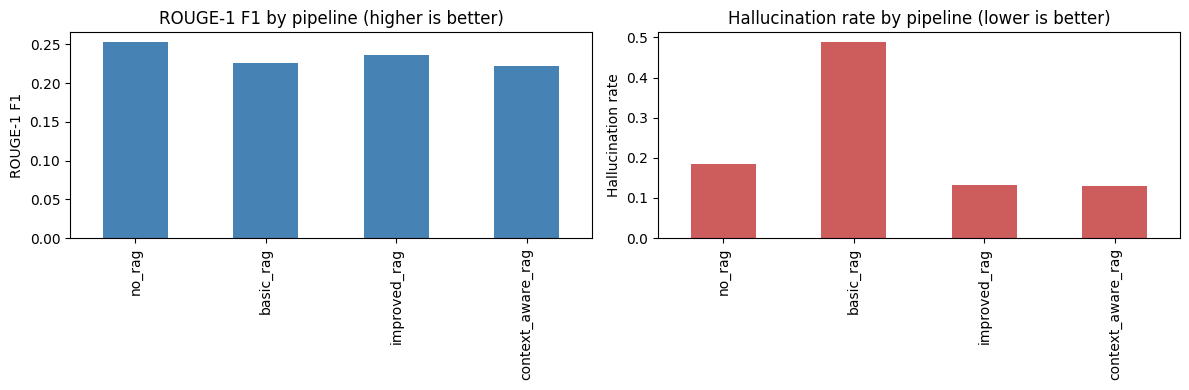

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rouge_summary['rouge_1_f1'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('ROUGE-1 F1 by pipeline (higher is better)')
axes[0].set_ylabel('ROUGE-1 F1')
axes[0].set_xlabel('')

factual_summary['hallucination_rate'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Hallucination rate by pipeline (lower is better)')
axes[1].set_ylabel('Hallucination rate')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 8. Official winner tables

These are the exact outputs `aggregate_winner_table.py` writes to `results/final_analysis/` - per-metric winners and each method's percentage change vs. the no-RAG baseline.

In [12]:
from pathlib import Path
from IPython.display import display

winner_wide_path = Path('results/final_analysis/winner_table_wide.csv')
comparison_path = Path('results/final_analysis/comparison_vs_no_rag.csv')

if winner_wide_path.exists():
    display(pd.read_csv(winner_wide_path))
else:
    print(f'{winner_wide_path} not found yet - run the aggregation step above first.')

,budget,factual_f1,factual_precision,hallucination_rate,importance_weighted_key_fact_recall,rouge_1_f1,rouge_1_precision,rouge_1_recall,unclear_rate
0,4000,no_rag,context_aware_rag,context_aware_rag,no_rag,no_rag,improved_rag,no_rag,basic_rag


In [13]:
if comparison_path.exists():
    display(pd.read_csv(comparison_path))
else:
    print(f'{comparison_path} not found yet - run the aggregation step above first.')

,budget,pipeline_name,rouge_1_precision,rouge_1_recall,rouge_1_f1,factual_precision,importance_weighted_key_fact_recall,factual_f1,hallucination_rate,unclear_rate,...,factual_precision_pct_change_vs_no_rag,importance_weighted_key_fact_recall_diff_vs_no_rag,importance_weighted_key_fact_recall_pct_change_vs_no_rag,factual_f1_diff_vs_no_rag,factual_f1_pct_change_vs_no_rag,hallucination_rate_diff_vs_no_rag,hallucination_rate_pct_change_vs_no_rag,unclear_rate_diff_vs_no_rag,unclear_rate_pct_change_vs_no_rag,hallucination_reduction_pct_vs_no_rag
0,4000,basic_rag,0.648992,0.137694,0.226520,0.511765,0.296640,0.349914,0.488235,0.0,...,-37.228179,-0.481963,-61.900977,-0.445023,-55.982204,0.303513,164.307828,0.0,NaN,-164.307828
1,4000,context_aware_rag,0.704068,0.132368,0.222580,0.871429,0.681256,0.755195,0.128571,0.0,...,6.887321,-0.097347,-12.502839,-0.039742,-4.999382,-0.056151,-30.397422,0.0,NaN,30.397422
2,4000,improved_rag,0.717712,0.141952,0.236777,0.867965,0.688948,0.759434,0.132035,0.0,...,6.462532,-0.089655,-11.514876,-0.035503,-4.466114,-0.052688,-28.522605,0.0,NaN,28.522605
3,4000,no_rag,0.680199,0.155803,0.253033,0.815278,0.778603,0.794937,0.184722,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN,0.000000


---
**Testing multiple token budgets?** Change `config.max_source_tokens` in the "recreate project files" step, then re-run from step 4 onward - just move or rename `results/metrics.csv` and `results/factual_eval/factual_metrics.csv` somewhere budget-specific before the next run, or they'll be overwritten.